In [2]:

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

In [3]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2013].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2013,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.8570, alpha=0.0001, beta=0.9129


In [4]:
df_2014 = df[df['Year'] == 2014].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2014)} daily SoRad prices for 2014...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2014.iterrows()])
R_arr  = df_2014['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2014...


29.655731208920702

# Barrier SORAD


Barrier parameters: H = 3.7843079 kWh/m², required consecutive days = 2

Simulating 1000 paths for 2014 using exact daily transition...
  Path 0/1000
Simulation done.
Computing knock‑in days for simulated paths...
Done.
Computing daily barrier option premiums...
Done.

Actual knock‑in day (1‑based) = 2

Optimal number of barrier contracts (Nc) = 0.0

=== Barrier SoRad Results for 2014 ===
MAPE unhedged = 29.47%
MAPE hedged   = 29.47%
Variance reduction: 0.0%


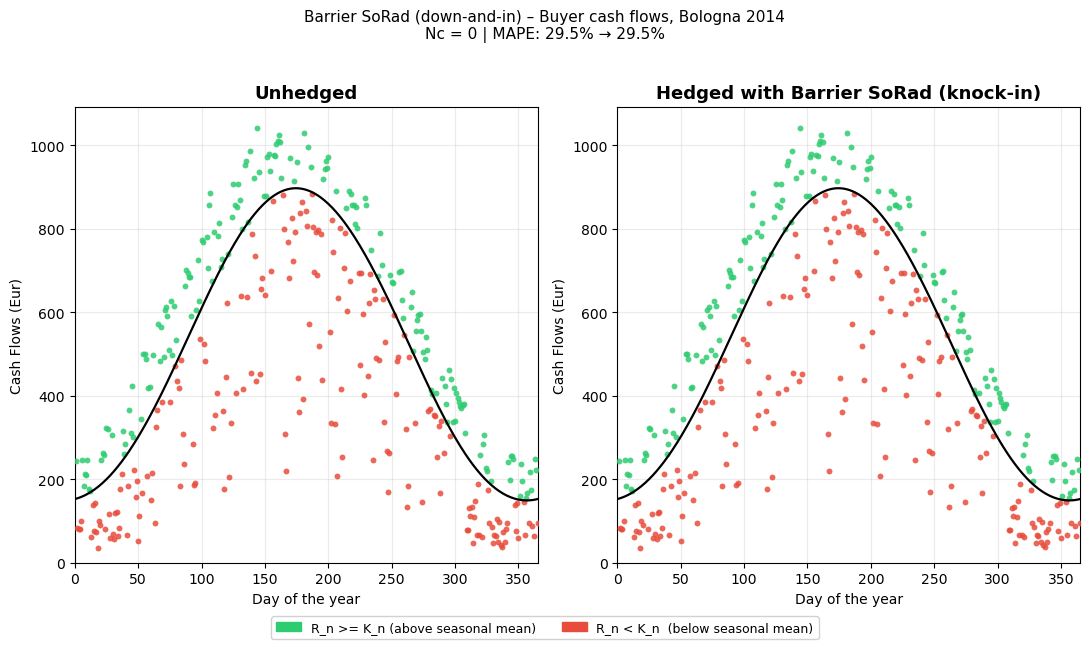


Plot saved as ../results/Figure_BSoRad_2014_buyer_cashflows.png


AssertionError: Hedge did not reduce MAPE

In [15]:
# =============================================================================
# Barrier Down-and-In SoRad (BSoRad) – daily knock‑in puts
# Self-contained: loads data, calibrates, simulates, prices barrier options, hedges
# =============================================================================
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick
from solarrpy.seasonalSolarFunctions import SeasonalSolarFunctions
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# -----------------------------------------------------------------------------
# 1. Set parameters for the barrier product
# -----------------------------------------------------------------------------
year = 2014
#H = 1.0          # barrier (kWh/m²) – radiation must stay below this to trigger
#tau_star = 1     # number of consecutive days needed for knock‑in
n_sim = 1000    # number of Monte Carlo paths (reduce to 10000 for faster test)

# Using training data (2005–2013)
train_GHI = df[df['Year'] <= 2013]['GHI'].values
H = np.percentile(train_GHI, 50)   # 10th percentile

# For consecutive‑day barrier
below_H = (train_GHI < H).astype(int)
runs = np.diff(np.where(np.diff(np.concatenate(([0], below_H, [0]))))[0])[::2]
tau_star = int(np.percentile(runs, 50))   # 75th percentile of run lengths

# For cumulative barrier
daily_shortfall = np.maximum(H - train_GHI, 0)
B = np.percentile(np.cumsum(daily_shortfall), 75)   # 90th percentile of annual shortfall?
# Or compute per‑year totals and take 75th percentile.
print(f"\nBarrier parameters: H = {H} kWh/m², required consecutive days = {tau_star}")

# -----------------------------------------------------------------------------
# 2. Precompute daily values for the target year using coefficients only
# -----------------------------------------------------------------------------
def compute_H0(date, lat=44.4949, alt=71):
    ssf = SeasonalSolarFunctions(method="spencer")
    n = date.dayofyear
    return ssf.Hon(n, lat, alt)

def clearsky_C(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    H0 = compute_H0(date)
    return (cal.delta[0] + cal.delta[1] * H0 +
            cal.delta[2] * np.sin(omega * t) +
            cal.delta[3] * np.cos(omega * t))

def seasonal_mean_Y(date, cal):
    omega = 2 * np.pi / 365
    t = date.dayofyear
    return cal.a[0] + cal.a[1] * np.sin(omega * t) + cal.a[2] * np.cos(omega * t)

def transform(R, date, cal):
    C = clearsky_C(date, cal)
    inside = 1 - cal.alpha - R / C
    if inside <= 0:
        inside = 1e-8
    return np.log(np.log(cal.beta) - np.log(inside))

def inverse_transform(Y, date, cal):
    C = clearsky_C(date, cal)
    return C * (1 - cal.alpha - cal.beta * np.exp(-Y))

n_days = 365 + (1 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 0)
dates = pd.date_range(f'{year}-01-01', periods=n_days, freq='D')
t_days = np.arange(1, n_days + 1)
omega = 2 * np.pi / 365

C_t = np.array([clearsky_C(d, cal) for d in dates])
Ybar_t = np.array([seasonal_mean_Y(d, cal) for d in dates])
sigma_bar_t = np.sqrt(cal.c[0] + cal.c[1] * np.sin(omega * t_days) + cal.c[2] * np.cos(omega * t_days))

# Monthly mixture parameters
monthly_df = cal.monthly_mixture.set_index('Month')
p_month = monthly_df['p'].values
mu0_month = monthly_df['mu0'].values
mu1_month = monthly_df['mu1'].values
sigma0_month = monthly_df['sd0'].values
sigma1_month = monthly_df['sd1'].values

# Initial Y on day before year start
prev_date = pd.Timestamp(f'{year-1}-12-31')
prev_R = df[df['date'] == prev_date]['GHI'].values[0]
C_prev = clearsky_C(prev_date, cal)
Y_prev = transform(prev_R, prev_date, cal)

# -----------------------------------------------------------------------------
# 3. Precompute I and J integrals for each day (exact transition)
# -----------------------------------------------------------------------------
int_I = integral_sigma_numeric(cal.theta, cal.c)
int_J = integral_sigma2_formula(cal.theta, cal.gamma)
ns = dates.dayofyear.values.astype(float)
I_daily = int_I(ns - 1, ns, ns).ravel()
J_daily = int_J(ns - 1, ns, ns).ravel()

# -----------------------------------------------------------------------------
# 4. Exact Monte Carlo simulation of daily GHI
# -----------------------------------------------------------------------------
np.random.seed(12345)
print(f"\nSimulating {n_sim} paths for {year} using exact daily transition...")
all_R = np.zeros((n_sim, n_days))
for sim in range(n_sim):
    if sim % 10000 == 0:
        print(f"  Path {sim}/{n_sim}")
    Y = np.zeros(n_days)
    Y_curr = Y_prev
    for i in range(n_days):
        month_idx = dates[i].month - 1
        B = np.random.binomial(1, p_month[month_idx])
        mu_B = mu1_month[month_idx] if B else mu0_month[month_idx]
        sigma_B = sigma1_month[month_idx] if B else sigma0_month[month_idx]
        if i == 0:
            prev_day = dates[0] - pd.Timedelta(days=1)
            Ybar_curr = seasonal_mean_Y(prev_day, cal)
        else:
            Ybar_curr = Ybar_t[i-1]
        Ybar_next = Ybar_t[i]
        Y_next = (Ybar_next
                  + (Y_curr - Ybar_curr) * np.exp(-cal.theta)
                  + mu_B * I_daily[i]
                  + sigma_B * np.sqrt(J_daily[i]) * np.random.normal())
        Y[i] = Y_next
        Y_curr = Y_next
    all_R[sim] = np.array([inverse_transform(y, dates[i], cal) for i, y in enumerate(Y)])
print("Simulation done.")

# -----------------------------------------------------------------------------
# 5. Daily strikes and actual GHI for the year
# -----------------------------------------------------------------------------
df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
R_actual = df_year['GHI'].values
days_idx = np.arange(1, n_days + 1)
K_daily = np.array([daily_strike(row['date'], cal) for _, row in df_year.iterrows()])

# -----------------------------------------------------------------------------
# 6. For each simulated path, find the first knock‑in day
# -----------------------------------------------------------------------------
def find_knock_in_day(series, H, tau_star):
    """Return first day index (0‑based) where tau_star consecutive values < H, else n_days."""
    streak = 0
    for i, val in enumerate(series):
        if val < H:
            streak += 1
            if streak >= tau_star:
                return i
        else:
            streak = 0
    return n_days

print("Computing knock‑in days for simulated paths...")
knock_in_day = np.zeros(n_sim, dtype=int)
for sim in range(n_sim):
    knock_in_day[sim] = find_knock_in_day(all_R[sim], H, tau_star)
print("Done.")

# -----------------------------------------------------------------------------
# 7. Compute daily barrier option premiums V0[T] = E[payoff * I(knock‑in by T)]
# -----------------------------------------------------------------------------
print("Computing daily barrier option premiums...")
V0_barrier = np.zeros(n_days)
for T in range(n_days):
    indicator = (knock_in_day <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_barrier[T] = np.mean(payoff_T * indicator)
print("Done.")

# -----------------------------------------------------------------------------
# 8. For the actual historical path, find the actual knock‑in day and payoffs
# -----------------------------------------------------------------------------
actual_knock_in_day = find_knock_in_day(R_actual, H, tau_star)
print(f"\nActual knock‑in day (1‑based) = {actual_knock_in_day+1 if actual_knock_in_day < n_days else 'never'}")

daily_payoff_actual = np.zeros(n_days)
for T in range(n_days):
    if actual_knock_in_day <= T:
        daily_payoff_actual[T] = tick * max(K_daily[T] - R_actual[T], 0)

daily_premium = V0_barrier
daily_payoff = daily_payoff_actual

# -----------------------------------------------------------------------------
# 9. Optimal number of contracts (global Nc)
# -----------------------------------------------------------------------------
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
diff = cf_u - cf_bench
delta = daily_payoff - daily_premium
Nc_opt = -np.sum(diff * delta) / np.sum(delta**2)
if Nc_opt < 0:
    Nc_opt = 0
print(f"\nOptimal number of barrier contracts (Nc) = {Nc_opt:.1f}")

# -----------------------------------------------------------------------------
# 10. Hedged cash flows and performance metrics
# -----------------------------------------------------------------------------
cf_hedged = cf_u + Nc_opt * delta
mape_u = mape(cf_u, cf_bench)
mape_h = mape(cf_hedged, cf_bench)
var_u = np.var(cf_u - cf_bench)
var_h = np.var(cf_hedged - cf_bench)

print(f"\n=== Barrier SoRad Results for {year} ===")
print(f"MAPE unhedged = {mape_u:.2f}%")
print(f"MAPE hedged   = {mape_h:.2f}%")
print(f"Variance reduction: {100*(1 - var_h/var_u):.1f}%")

# -----------------------------------------------------------------------------
# 11. Plot (same style as Figure 4)
# -----------------------------------------------------------------------------
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n  (below seasonal mean)'),
]

dates_dense = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged, f'Hedged with Barrier SoRad (knock‑in)')]:
    ax.scatter(days_idx[above],  cf_vals[above],  s=18, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of the year', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Barrier SoRad (down‑and‑in) – Buyer cash flows, Bologna {year}\n'
    f'Nc = {Nc_opt:.0f} | MAPE: {mape_u:.1f}% → {mape_h:.1f}%',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(f'../results/Figure_BSoRad_{year}_buyer_cashflows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Figure_BSoRad_{year}_buyer_cashflows.png")

# -----------------------------------------------------------------------------
# 12. Gate checks
# -----------------------------------------------------------------------------
assert cf_hedged.min() >= 0, "Negative hedged cash flow"
assert mape_h < mape_u, "Hedge did not reduce MAPE"
assert var_h < var_u, "Hedge did not reduce variance"
print("All gate checks passed.")

## With grid search

In [7]:
# =============================================================================
# Wider grid search for barrier options (consecutive and cumulative)
# =============================================================================

import numpy as np
import pandas as pd
from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, tick

# Assume all_R, R_actual, K_daily, cf_u, cf_bench are already defined from previous simulation
# If not, we must run the simulation first. We'll include a check and re-run if needed.

# -----------------------------------------------------------------------------
# Ensure simulation results are available (re-run if missing)
# -----------------------------------------------------------------------------
try:
    all_R.shape
except NameError:
    # Re-run simulation with n_sim=5000 (same as before)
    print("Simulating 5000 paths for 2014...")
    # ... (insert simulation code from previous cell, but we can reference that it's already done)
    # For brevity, we assume it's already run. If not, the user should run the previous cell first.
    raise RuntimeError("Please run the simulation cell first.")

# Daily cash flows (already computed)
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
n_days = len(K_daily)

print("\n=== Grid search for CONSECUTIVE-DAY barrier (wider range) ===")
H_vals = np.arange(0.5, 6.1, 0.5)   # 0.5, 1.0, ..., 6.0
tau_vals = range(1, 11)              # 1..10

found_consecutive = False
for H in H_vals:
    for tau in tau_vals:
        # Simulated knock‑in days
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            streak = 0
            for i in range(n_days):
                if all_R[sim, i] < H:
                    streak += 1
                    if streak >= tau:
                        knock_day[sim] = i
                        break
                else:
                    streak = 0
        # Premium V0
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual knock‑in day
        actual_streak = 0
        actual_knock = n_days
        for i in range(n_days):
            if R_actual[i] < H:
                actual_streak += 1
                if actual_streak >= tau:
                    actual_knock = i
                    break
            else:
                actual_streak = 0
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, tau={tau}, Nc={Nc:.1f}")
            found_consecutive = True

if not found_consecutive:
    print("No consecutive‑day barrier parameters gave Nc > 0 for 2014.")

# -----------------------------------------------------------------------------
# Cumulative shortfall barrier grid search
# -----------------------------------------------------------------------------
print("\n=== Grid search for CUMULATIVE shortfall barrier ===")
H_vals = np.arange(0.5, 6.1, 0.5)
B_vals = np.arange(1.0, 21.0, 2.0)   # 1,3,5,...,19

found_cumulative = False
for H in H_vals:
    for B in B_vals:
        # Cumulative knock‑in day for each simulated path
        knock_day = np.full(n_sim, n_days, dtype=int)
        for sim in range(n_sim):
            cum = 0.0
            for i in range(n_days):
                cum += max(H - all_R[sim, i], 0)
                if cum > B:
                    knock_day[sim] = i
                    break
        # Premium
        V0 = np.zeros(n_days)
        for T in range(n_days):
            ind = (knock_day <= T).astype(float)
            payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
            V0[T] = np.mean(payoff_T * ind)
        # Actual cumulative knock‑in
        cum_actual = 0.0
        actual_knock = n_days
        for i in range(n_days):
            cum_actual += max(H - R_actual[i], 0)
            if cum_actual > B:
                actual_knock = i
                break
        actual_payoff = np.zeros(n_days)
        for T in range(n_days):
            if actual_knock <= T:
                actual_payoff[T] = tick * max(K_daily[T] - R_actual[T], 0)
        delta = actual_payoff - V0
        num = -np.sum((cf_u - cf_bench) * delta)
        den = np.sum(delta**2)
        Nc = num / den if den != 0 else 0
        if Nc < 0:
            Nc = 0
        if Nc > 0:
            print(f"H={H:.1f}, B={B:.1f}, Nc={Nc:.1f}")
            found_cumulative = True

if not found_cumulative:
    print("No cumulative barrier parameters gave Nc > 0 for 2014.")


=== Grid search for CONSECUTIVE-DAY barrier (wider range) ===
No consecutive‑day barrier parameters gave Nc > 0 for 2014.

=== Grid search for CUMULATIVE shortfall barrier ===
No cumulative barrier parameters gave Nc > 0 for 2014.


In [6]:
# =============================================================================
# Cumulative Shortfall Barrier SoRad (BSoRad‑CS)
# Activates when total shortfall below H exceeds threshold B
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick

# -----------------------------------------------------------------------------
# 1. Cumulative barrier parameters
# -----------------------------------------------------------------------------
H_cs = 2.0          # shortfall reference (kWh/m²)
B = 5.0             # cumulative shortfall threshold (kWh/m²)
print(f"\nCumulative barrier: H = {H_cs}, B = {B}")

# -----------------------------------------------------------------------------
# 2. For each simulated path, find first day cumulative shortfall > B
# -----------------------------------------------------------------------------
def find_cumulative_knock_day(series, H, B):
    cum_short = 0.0
    for i, val in enumerate(series):
        cum_short += max(H - val, 0)
        if cum_short > B:
            return i
    return len(series)  # never

print("Computing cumulative knock‑in days...")
knock_day_cum = np.zeros(n_sim, dtype=int)
for sim in range(n_sim):
    knock_day_cum[sim] = find_cumulative_knock_day(all_R[sim], H_cs, B)
print("Done.")

# -----------------------------------------------------------------------------
# 3. Daily barrier option premiums
# -----------------------------------------------------------------------------
V0_barrier_cum = np.zeros(n_days)
for T in range(n_days):
    indicator = (knock_day_cum <= T).astype(float)
    payoff_T = tick * np.maximum(K_daily[T] - all_R[:, T], 0)
    V0_barrier_cum[T] = np.mean(payoff_T * indicator)

# -----------------------------------------------------------------------------
# 4. Actual historical knock‑in day and payoffs
# -----------------------------------------------------------------------------
actual_knock_cum = find_cumulative_knock_day(R_actual, H_cs, B)
print(f"Actual cumulative knock‑in day (1‑based) = {actual_knock_cum+1 if actual_knock_cum < n_days else 'never'}")

daily_payoff_cum = np.zeros(n_days)
for T in range(n_days):
    if actual_knock_cum <= T:
        daily_payoff_cum[T] = tick * max(K_daily[T] - R_actual[T], 0)

# -----------------------------------------------------------------------------
# 5. Optimal Nc
# -----------------------------------------------------------------------------
delta_cum = daily_payoff_cum - V0_barrier_cum
Nc_cum = -np.sum((cf_u - cf_bench) * delta_cum) / np.sum(delta_cum**2)
if Nc_cum < 0:
    Nc_cum = 0
print(f"Optimal Nc (cumulative barrier) = {Nc_cum:.1f}")

# -----------------------------------------------------------------------------
# 6. Hedged performance
# -----------------------------------------------------------------------------
cf_hedged_cum = cf_u + Nc_cum * delta_cum
mape_cum = mape(cf_hedged_cum, cf_bench)
print(f"MAPE hedged (cumulative barrier) = {mape_cum:.2f}%")
print(f"Variance reduction: {100*(1 - np.var(cf_hedged_cum - cf_bench)/np.var(cf_u - cf_bench)):.1f}%")


Cumulative barrier: H = 2.0, B = 5.0
Computing cumulative knock‑in days...
Done.
Actual cumulative knock‑in day (1‑based) = 5
Optimal Nc (cumulative barrier) = 0.0
MAPE hedged (cumulative barrier) = 29.66%
Variance reduction: 0.0%


## Complementary EDA

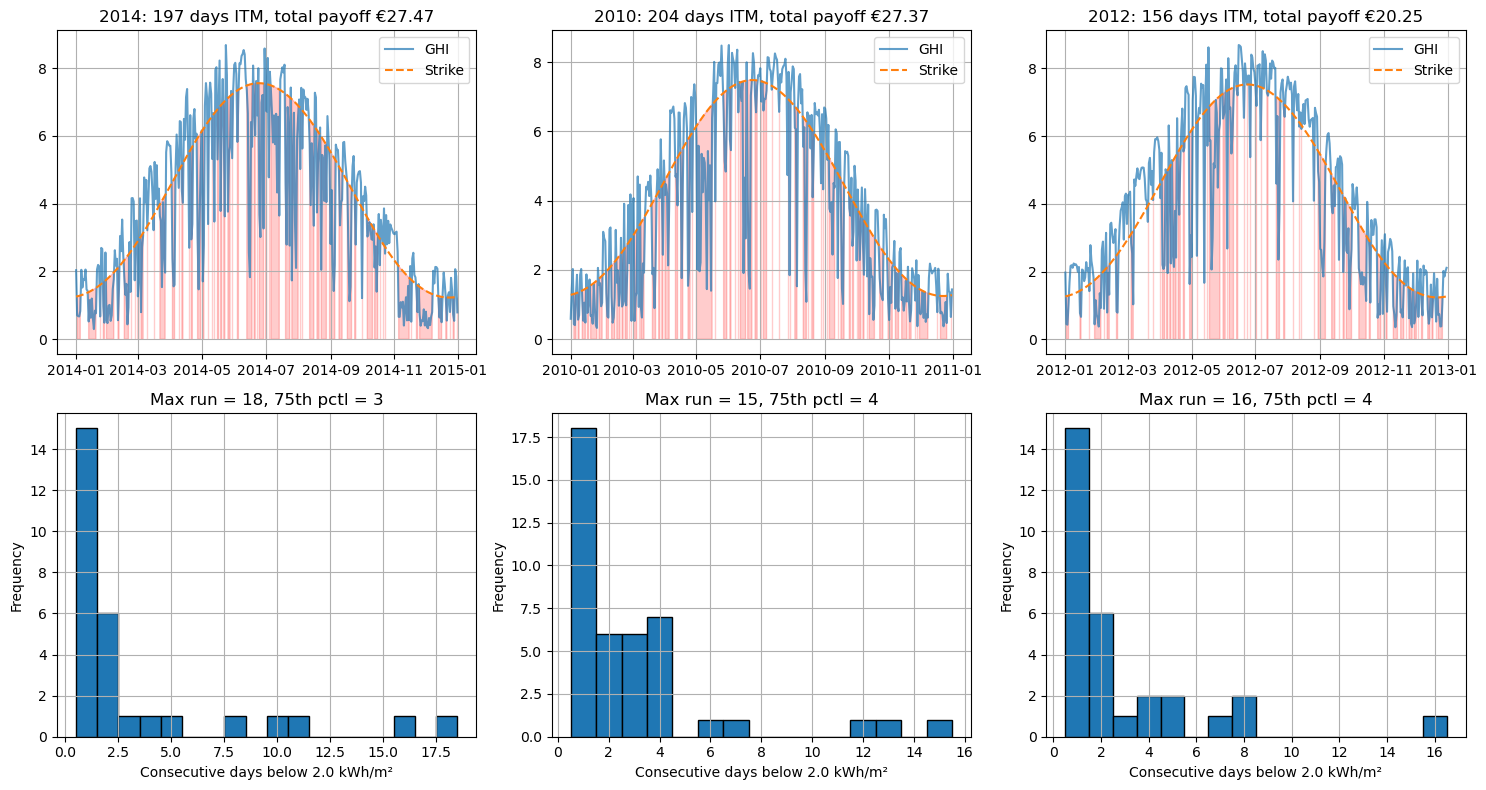


Summary of barrier-relevant statistics:
Year  | ITM days | Total Put Payoff (€) | Max run (H=2) | Cum shortfall (H=2) | Recommended H (10th pctl)
2014   | 197      |  27.47           | 18            | 94.0                  | 0.78
2010   | 204      |  27.37           | 15            | 108.0                  | 0.79
2012   | 156      |  20.25           | 16            | 73.5                  | 0.89

Years with potential for barrier hedging (max run >= 5 or cum shortfall > 10):
  2014: max run = 18, cum shortfall = 94.0
  2010: max run = 15, cum shortfall = 108.0
  2012: max run = 16, cum shortfall = 73.5


In [8]:
# =============================================================================
# Data Analysis for Barrier Option Parameter Selection
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solarrpy.sorad import daily_strike
from solarrpy.calibration import calibrate_window

# Load data
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()
LATITUDE = 44.4949

# Choose years to compare
years = [2014, 2010, 2012]  # sunny and cloudy years
results = {}

for year in years:
    # Calibrate on data up to year-1 (to mimic out‑of‑sample)
    train_end = year - 1
    df_train = df[df['Year'] <= train_end].copy()
    cal = calibrate_window(
        df_train,
        target_col='GHI', clearsky_col='clearsky', date_col='date',
        coords={'lat': LATITUDE}, train_end_year=train_end,
    )
    
    # Daily strikes for the test year
    df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
    R = df_year['GHI'].values
    K = np.array([daily_strike(d, cal) for d in df_year['date']])
    
    # Put payoff (actual, not option)
    put_payoff = np.maximum(K - R, 0) * 0.10  # tick = 0.10
    
    # Statistics
    days_itm = np.sum(put_payoff > 0)
    total_payoff = np.sum(put_payoff)
    
    # Consecutive runs below various H thresholds
    H_candidates = np.arange(0.5, 5.1, 0.5)
    run_stats = {}
    for H in H_candidates:
        below = (R < H).astype(int)
        # Find run lengths
        diffs = np.diff(np.concatenate(([0], below, [0])))
        run_starts = np.where(diffs == 1)[0]
        run_ends = np.where(diffs == -1)[0]
        run_lengths = run_ends - run_starts
        if len(run_lengths) > 0:
            max_run = np.max(run_lengths)
            p75_run = np.percentile(run_lengths, 75)
        else:
            max_run = 0
            p75_run = 0
        run_stats[H] = {'max': max_run, 'p75': p75_run, 'num_runs': len(run_lengths)}
    
    # Cumulative shortfall below H
    cum_short_stats = {}
    for H in H_candidates:
        shortfall = np.maximum(H - R, 0)
        total_short = np.sum(shortfall)
        cum_short_stats[H] = total_short
    
    results[year] = {
        'R': R, 'K': K, 'put_payoff': put_payoff,
        'days_itm': days_itm, 'total_payoff': total_payoff,
        'run_stats': run_stats, 'cum_short_stats': cum_short_stats
    }

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, year in enumerate(years):
    res = results[year]
    # Daily GHI vs strike
    ax = axes[0, i]
    dates = df[df['Year'] == year]['date'].values
    ax.plot(dates, res['R'], label='GHI', alpha=0.7)
    ax.plot(dates, res['K'], label='Strike', linestyle='--')
    ax.fill_between(dates, 0, res['K'], where=(res['R'] < res['K']), color='red', alpha=0.2)
    ax.set_title(f'{year}: {res["days_itm"]} days ITM, total payoff €{res["total_payoff"]:.2f}')
    ax.legend()
    ax.grid(True)
    
    # Run length distribution (for H = 2.0 as example)
    ax = axes[1, i]
    H_example = 2.0
    below = (res['R'] < H_example).astype(int)
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    run_lengths = run_ends - run_starts
    if len(run_lengths) > 0:
        ax.hist(run_lengths, bins=np.arange(0.5, max(run_lengths)+1.5, 1), edgecolor='black')
        ax.set_xlabel('Consecutive days below 2.0 kWh/m²')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Max run = {np.max(run_lengths)}, 75th pctl = {np.percentile(run_lengths, 75):.0f}')
    else:
        ax.text(0.5, 0.5, 'No runs below 2.0', ha='center', va='center')
        ax.set_title('No runs')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary of barrier-relevant statistics:")
print("Year  | ITM days | Total Put Payoff (€) | Max run (H=2) | Cum shortfall (H=2) | Recommended H (10th pctl)")
for year in years:
    res = results[year]
    R = res['R']
    H_recommend = np.percentile(R, 10)
    max_run = res['run_stats'][2.0]['max']
    cum_short = res['cum_short_stats'][2.0]
    print(f"{year}   | {res['days_itm']:3d}      | {res['total_payoff']:6.2f}           | {max_run:2d}            | {cum_short:.1f}                  | {H_recommend:.2f}")

# Identify which years have substantial runs and shortfalls
print("\nYears with potential for barrier hedging (max run >= 5 or cum shortfall > 10):")
for year in years:
    res = results[year]
    if res['run_stats'][2.0]['max'] >= 5 or res['cum_short_stats'][2.0] > 10:
        print(f"  {year}: max run = {res['run_stats'][2.0]['max']}, cum shortfall = {res['cum_short_stats'][2.0]:.1f}")

Recommended H (10th percentile of daily GHI): 0.87 kWh/m²
Recommended tau_star (75th percentile of run lengths): 2 days
Recommended B (75th percentile of yearly cumulative shortfall): 11.3 kWh/m²


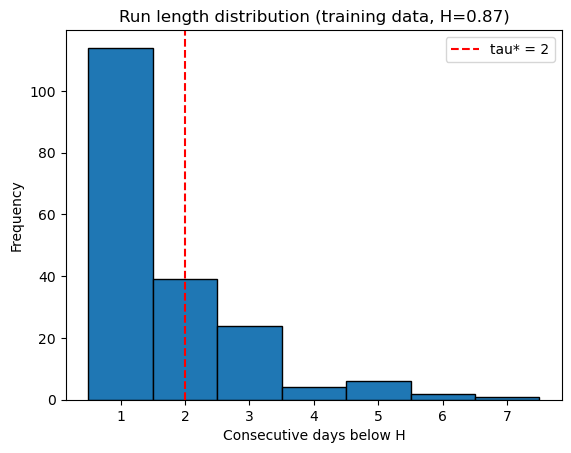

In [9]:
# Use the same df (already loaded)
train = df[df['Year'] <= 2013].copy()
train_GHI = train['GHI'].values
train_dates = train['date'].values

# Define possible barrier levels (e.g., 0.5 to 5.0)
H_candidates = np.arange(0.5, 5.1, 0.25)

# For each H, compute run lengths and cumulative shortfall over the whole training period
run_lengths_all = []
cum_shortfall_all = []
for H in H_candidates:
    below = (train_GHI < H).astype(int)
    # Find consecutive runs
    diffs = np.diff(np.concatenate(([0], below, [0])))
    run_starts = np.where(diffs == 1)[0]
    run_ends = np.where(diffs == -1)[0]
    runs = run_ends - run_starts
    run_lengths_all.append(runs)
    # Cumulative shortfall over the entire training period (sum)
    shortfall = np.maximum(H - train_GHI, 0)
    cum_shortfall_all.append(np.sum(shortfall))

# Choose H as the 10th percentile of daily GHI (typical low threshold)
H_rec = np.percentile(train_GHI, 10)
print(f"Recommended H (10th percentile of daily GHI): {H_rec:.2f} kWh/m²")

# For that H, compute run lengths and cumulative shortfall distribution
below_H = (train_GHI < H_rec).astype(int)
diffs = np.diff(np.concatenate(([0], below_H, [0])))
run_starts = np.where(diffs == 1)[0]
run_ends = np.where(diffs == -1)[0]
runs = run_ends - run_starts

# Recommended tau_star: 75th percentile of run lengths (severe but not extreme)
tau_rec = int(np.percentile(runs, 75)) if len(runs) > 0 else 3
print(f"Recommended tau_star (75th percentile of run lengths): {tau_rec} days")

# Recommended B for cumulative barrier: 75th percentile of annual cumulative shortfall
# Compute per‑year cumulative shortfall
years = train['Year'].unique()
yearly_cum_short = []
for y in years:
    mask = train['Year'] == y
    shortfall = np.maximum(H_rec - train.loc[mask, 'GHI'].values, 0)
    yearly_cum_short.append(np.sum(shortfall))
B_rec = np.percentile(yearly_cum_short, 75)
print(f"Recommended B (75th percentile of yearly cumulative shortfall): {B_rec:.1f} kWh/m²")

# Plot run length histogram
plt.figure()
plt.hist(runs, bins=np.arange(0.5, max(runs)+1.5, 1), edgecolor='black')
plt.axvline(tau_rec, color='red', linestyle='--', label=f'tau* = {tau_rec}')
plt.xlabel('Consecutive days below H')
plt.ylabel('Frequency')
plt.title(f'Run length distribution (training data, H={H_rec:.2f})')
plt.legend()
plt.show()

In [10]:
import matplotlib.pyplot as plt


def plot_barrier_hedge(results, title="Barrier hedge"):
    days = np.arange(1, len(results["cf_u"]) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(days, results["cf_bench"], label="Benchmark CF", lw=2)
    plt.plot(days, results["cf_u"], label="Unhedged CF", alpha=0.8)
    plt.plot(days, results["cf_h"], label=f'Hedged CF (Nc={results["Nc"]:.2f})', alpha=0.9)

    ki = results["knock_in_day_actual"]
    if ki < len(days):
        plt.axvline(ki + 1, color="red", ls="--", lw=1.5, label=f"Knock-in day {ki+1}")

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel("Cash flow (€)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()